<a href="https://colab.research.google.com/github/andreagrioni/Tutorials/blob/master/02_sequence_complementarity_heatmaps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02_sequence_complementarity_heatmaps
Visualize sequence-sequence complementarity could be 

useful to better understand the molecular mechanisms

of cell regulations (e.g. transcriptional factors

binding sites). In this code you will implement

a small script to visualize sequence to sequence 

complementary through heatmaps.

In [0]:
# library
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

## define interaction metrics

Herein you can find two main functions that allows the
creation of the interaction matrics.

In [0]:
def watson_crick(
    x_,
    y_,
    alphabet=['AT','GC','CG','TA']
  ):
    '''
    fun assigns 1 if input string
    is in alphabet, otherwise
    it returns 0.
    
    parameters:
    x_ = nt_x
    y_ = nt_y
    alphabet = list of nt combinations
    '''
    if f'{x_}{y_}' in alphabet:
        return 1
    return 0

def make_set_hm(seq_x, seq_y):
    '''
    fun creates a metrics of nt bindings
    according to watson crick rules.
    output is a metrics of 0 or 1 (not bind
    or bind)
    
    parameters
    x = nt sequence for x axis
    y = nt sequence for y axis
    '''
    len_x = len(seq_x)
    len_y = len(seq_y)
    metrics = np.zeros( (len_x, len_y) )

    for i_bind in range(0, len_x):
        for i_micro in range(0, len_y):
            metrics[i_bind, i_micro] = watson_crick(x[i_bind], y[i_micro])
    
    m_out = pd.DataFrame(metrics, columns = list(y), index = list(x))
    return m_out

## Callers
This function generates the heatmap based on the interaction matrix.

In [0]:
#final_with_binding_and_mirna_seq
def make_2d(x_ , y_):
    '''
    fun plots 2D metrics of watson-crick binding
    rules of sequence x and y as heatmap

    x_ = nt binding seq
    y_ = nt mirna seq
    '''
    # Create binding site - mirna interaction metrics
    df = make_set_hm(x_, y_)    
    # Default heatmap: just a visualization of this square matrix

    ax = sns.heatmap(
        df,
        xticklabels = True,
        yticklabels = True,
        annot = False,
        cbar = False,
        vmin = 0,
        vmax = 1        
        )
    return ax

## run toy sequences

you define two sequence, and an interaction heatmaps will be generated.

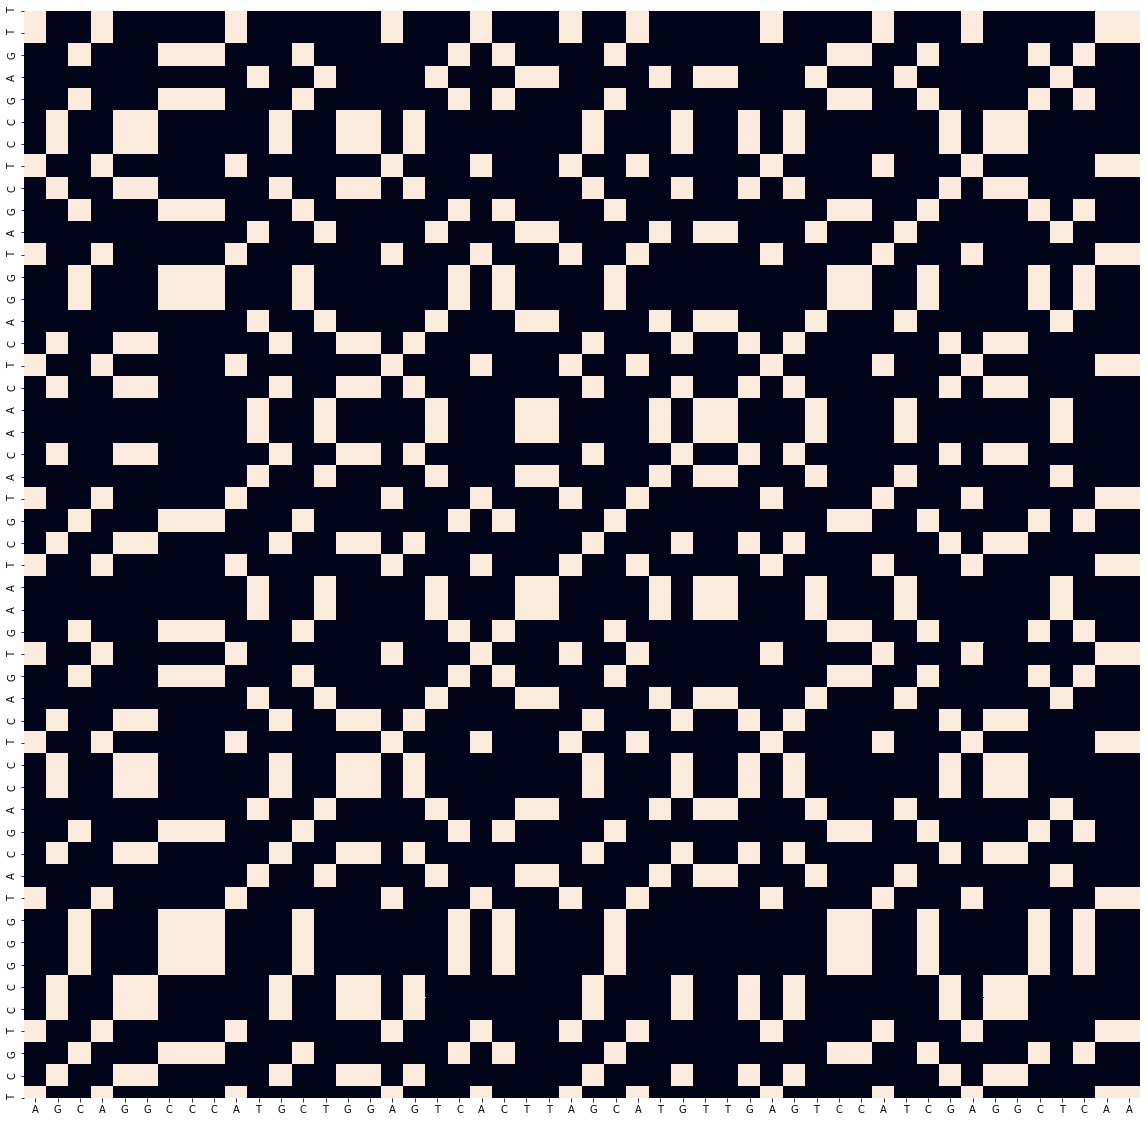

In [0]:
x = 'TTGAGCCTCGATGGACTCAACATGCTAAGTGACTCCAGCATGGGCCTGCT'
y = 'AGCAGGCCCATGCTGGAGTCACTTAGCATGTTGAGTCCATCGAGGCTCAA'

#print_2d('x', 'x')
fig, ax = plt.subplots(figsize=(20, 20))

ax = make_2d(x, y)
fig.show()

fig.savefig('./test.png')